In [1]:
!pip3 install scikit-image
!pip3 install torchsummary
!pip3 install matplotlib
!pip3 install librosa


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip3 install kagglehub


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("mohammedalrajeh/quran-recitations-for-audio-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\prativadis\.cache\kagglehub\datasets\mohammedalrajeh\quran-recitations-for-audio-classification\versions\1


In [7]:
import torch
from torch import nn
from torch.optim import Adam
import time
import librosa
from torch.utils.data import DataLoader,Dataset
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from skimage.transform import resize
device="cuda" if torch.cuda.is_available() else "cpu"


In [8]:
df=pd.read_csv("files_paths.csv")

In [13]:
df.columns

Index(['FilePath', 'Class'], dtype='object')

In [10]:
print(df["Class"].unique())
print(len(df["Class"].unique()))
df.head()

['Mohammed_Aluhaidan' 'Yasser_Aldossary' 'Maher_Almuaiqly'
 'Nasser_Alqutami' 'AbdulBari_Althubaity' 'Bander_Balilah'
 'Ali_Alhothaify' 'Saud_Alshuraim' 'Mohammed_Ayoub' 'AbdulRahman_Alsudais'
 'Saad_Alghamdi' 'Abdullah_Albuaijan']
12


,FilePath,Class
0,./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav,Mohammed_Aluhaidan
1,./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav,Mohammed_Aluhaidan
2,./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav,Mohammed_Aluhaidan
3,./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav,Mohammed_Aluhaidan
4,./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav,Mohammed_Aluhaidan


In [37]:
import os

base_dir = r"C:\Users\prativadis\OneDrive - TESSCO Technologies\Desktop\pytorch projects\fourth_project\quran-recitations-for-audio-classification\Dataset\Dataset"

# If your dataframe has subfolders and filenames:
df["FilePath"] = df["FilePath"].apply(lambda x: os.path.join(base_dir, x))


In [38]:
df.head()

,FilePath,Class
0,C:\Users\prativadis\OneDrive - TESSCO Technolo...,Mohammed_Aluhaidan
1,C:\Users\prativadis\OneDrive - TESSCO Technolo...,Mohammed_Aluhaidan
2,C:\Users\prativadis\OneDrive - TESSCO Technolo...,Mohammed_Aluhaidan
3,C:\Users\prativadis\OneDrive - TESSCO Technolo...,Mohammed_Aluhaidan
4,C:\Users\prativadis\OneDrive - TESSCO Technolo...,Mohammed_Aluhaidan


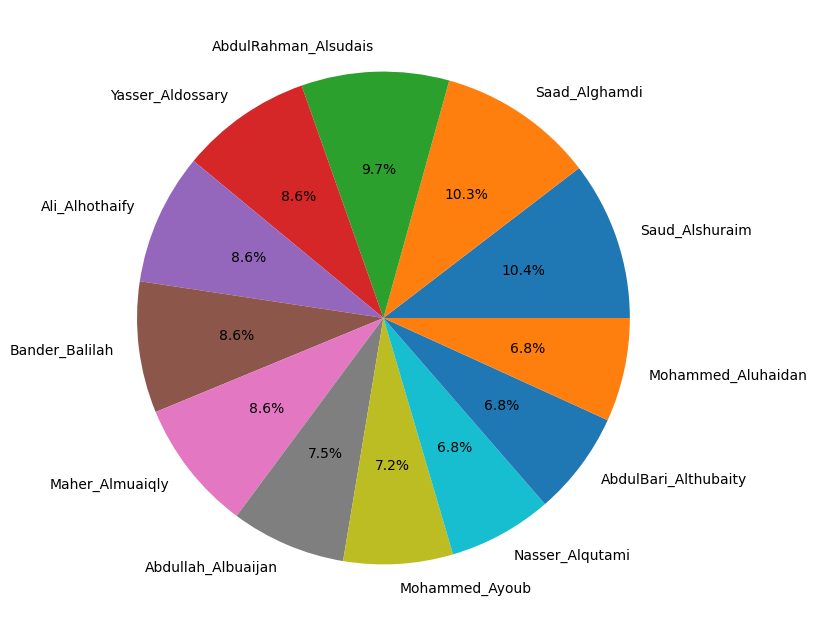

In [23]:
plt.figure(figsize=(8,8))
plt.pie(df['Class'].value_counts(),labels=df['Class'].value_counts().index,autopct='%1.1f%%')
plt.show()

In [31]:
train=df.sample(frac=0.7,random_state=7)
test=df.drop(train.index)
val=test.sample(frac=0.5,random_state=7)
print('Train shape',train.shape)
print('val shape',val.shape)
print('test shape',test.shape)


Train shape (4681, 2)
val shape (1003, 2)
test shape (2006, 2)


In [25]:
lb=LabelEncoder()

In [76]:
import os
import torch
import librosa
from torch.utils.data import Dataset
from skimage.transform import resize

class CustomAudioDataset(Dataset):
    def __init__(self, dataframe, label_encoder, device="cpu"):
        # Drop rows where file doesn't exist
        dataframe = dataframe[dataframe["FilePath"].apply(os.path.exists)].reset_index(drop=True)
        self.dataframe = dataframe
        self.labels = torch.tensor(
            label_encoder.fit_transform(self.dataframe["Class"]),
            dtype=torch.long
        )
        self.device = device

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        file_path = self.dataframe.iloc[idx]["FilePath"]
        audio = torch.tensor(self.get_spectrogram(file_path), dtype=torch.float32).unsqueeze(0)
        label = self.labels[idx]
        return audio.to(self.device), label.to(self.device)

    def get_spectrogram(self, file_path):
        sr = 22050
        duration = 5
        signal, sr = librosa.load(file_path, sr=sr, duration=duration)
        spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
        spec_db = librosa.power_to_db(spec, ref=np.max)
        spec_resized = resize(spec_db, (128, 256), anti_aliasing=True)
        return spec_resized


In [77]:
import os

base_dir = r"C:\Users\prativadis\OneDrive - TESSCO Technologies\Desktop\pytorch projects\fourth_project\quran-recitations-for-audio-classification\Dataset\Dataset"

for df in [train, val, test]:
    df["FilePath"] = df["FilePath"].apply(lambda x: os.path.join(base_dir, x))


In [78]:
for df in [train, val, test]:
    df = df[df["FilePath"].apply(os.path.exists)]

In [80]:
lr=LabelEncoder()

In [82]:
train_dataset = CustomAudioDataset(dataframe=train, label_encoder=lb, device=device)
val_dataset   = CustomAudioDataset(dataframe=val, label_encoder=lb, device=device)
test_dataset  = CustomAudioDataset(dataframe=test, label_encoder=lb, device=device)


In [84]:
lr=1e-4
BATCH_SIZE=16
epochs=25

In [83]:
train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=True)

ValueError: num_samples should be a positive integer value, but got num_samples=0

In [ ]:
# import torch
# import torch.nn as nn

# class Net(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()
#         self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
#         self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
#         self.pool = nn.MaxPool2d(2, 2)
#         self.relu = nn.ReLU()
#         self.dropout = nn.Dropout(0.5)

#         # Compute flattened size dynamically
#         flattened_size = self._get_flattened_size((1, 128, 256))

#         # Fully connected layers
#         self.linear1 = nn.Linear(flattened_size, 1024)
#         self.linear2 = nn.Linear(1024, 512)
#         self.output = nn.Linear(512, num_classes)

#     def _get_flattened_size(self, input_shape):
#         with torch.no_grad():
#             x = torch.zeros(1, *input_shape)  # dummy input
#             x = self.relu(self.conv1(x))
#             x = self.pool(x)
#             x = self.relu(self.conv2(x))
#             x = self.pool(x)
#             return x.numel() // x.shape[0]  # remove batch dimension

#     def forward(self, x):
#         x = self.relu(self.conv1(x))
#         x = self.pool(x)
#         x = self.relu(self.conv2(x))
#         x = self.pool(x)
#         x = torch.flatten(x, 1)
#         x = self.relu(self.linear1(x))
#         x = self.dropout(x)
#         x = self.relu(self.linear2(x))
#         x = self.dropout(x)
#         x = self.output(x)
#         return x


In [85]:
model = Net(num_classes=len(df['Class'].unique())).to(device)
from torchsummary import summary
summary(model, (1, 128, 256))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
              ReLU-2         [-1, 16, 128, 256]               0
         MaxPool2d-3          [-1, 16, 64, 128]               0
            Conv2d-4          [-1, 32, 64, 128]           4,640
              ReLU-5          [-1, 32, 64, 128]               0
         MaxPool2d-6           [-1, 32, 32, 64]               0
            Linear-7                 [-1, 1024]      67,109,888
              ReLU-8                 [-1, 1024]               0
           Dropout-9                 [-1, 1024]               0
           Linear-10                  [-1, 512]         524,800
             ReLU-11                  [-1, 512]               0
          Dropout-12                  [-1, 512]               0
           Linear-13                    [-1, 0]               0
Total params: 67,639,488
Trainable para

c:\Users\prativadis\OneDrive - TESSCO Technologies\Desktop\pytorch projects\.venv\Lib\site-packages\torch\nn\init.py:582: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [86]:
criterion=nn.CrossEntropyLoss()
optimizer=Adam(model.parameters(),lr=lr)

In [87]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(epochs):
    # Reset metrics
    total_acc_train = 0
    total_loss_train = 0
    total_loss_val = 0
    total_acc_val = 0

    # ---------------- Training ----------------
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        train_loss.backward()
        optimizer.step()

        # Accumulate metrics
        total_loss_train += train_loss.item() * inputs.size(0)   # multiply by batch size
        total_acc_train += (torch.argmax(outputs, dim=1) == labels).sum().item()

    # ---------------- Validation ----------------
    model.eval()
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_loss = criterion(outputs, labels)

            total_loss_val += val_loss.item() * inputs.size(0)   # multiply by batch size
            total_acc_val += (torch.argmax(outputs, dim=1) == labels).sum().item()

    # ---------------- Epoch Metrics ----------------
    avg_train_loss = total_loss_train / len(train_dataset)
    avg_val_loss = total_loss_val / len(val_dataset)

    train_acc = total_acc_train / len(train_dataset) * 100
    val_acc = total_acc_val / len(val_dataset) * 100

    # Save for plotting
    total_loss_train_plot.append(avg_train_loss)
    total_loss_validation_plot.append(avg_val_loss)
    total_acc_train_plot.append(train_acc)
    total_acc_validation_plot.append(val_acc)

    # Print progress
    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Train Acc: {train_acc:.2f}%, "
          f"Val Loss: {avg_val_loss:.4f}, "
          f"Val Acc: {val_acc:.2f}%")


IndexError: index 333 is out of bounds for dimension 0 with size 0

In [74]:
with torch.no_grad():
    total_acc_test = 0
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        predictions = model(inputs)
        total_acc_test += (torch.argmax(predictions, dim=1) == labels).sum().item()

accuracy = total_acc_test / len(test_dataset) * 100
print(f"Total Accuracy Score is {accuracy:.4f}%")


IndexError: index 1497 is out of bounds for dimension 0 with size 0

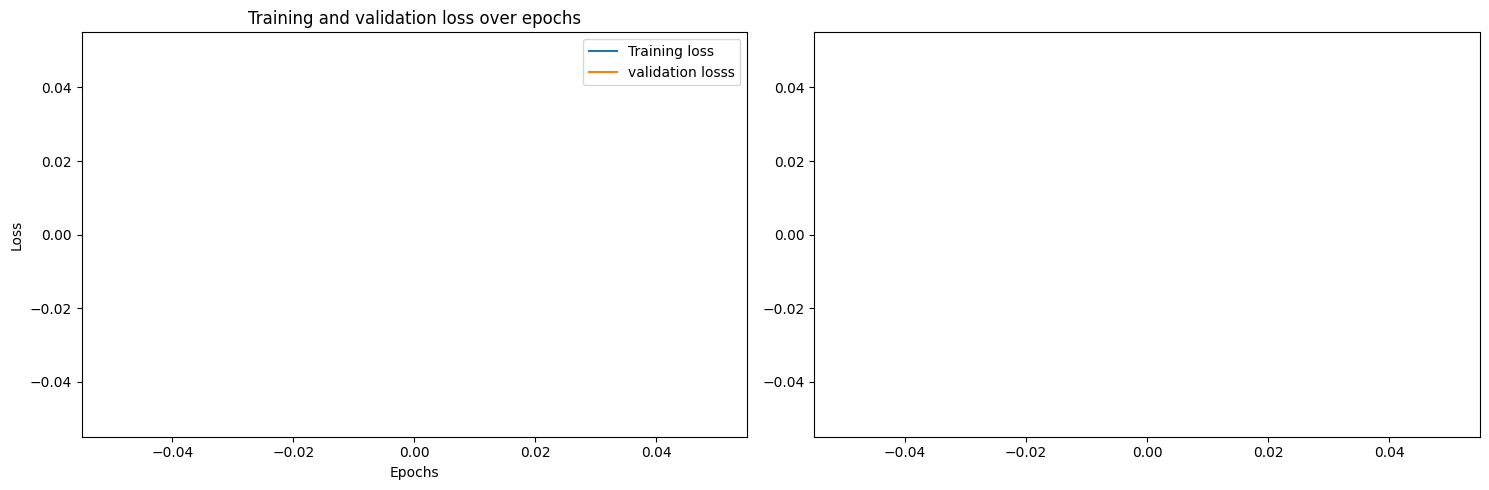

In [ ]:
fig,axs=plt.subplots(nrows=1,ncols=2,figsize=(15,5))
axs[0].plot(total_loss_train_plot,label='Training loss')
axs[0].plot(total_acc_validation_plot,label='validation losss')
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].set_title("Training and validation loss over epochs")
axs[0].legend()
axs[1].plot(total_acc_train_plot,label='Training Accuracy')
axs[1].plot(total_acc_validation_plot,label='Training Accuracy')
plt.tight_layout()
plt.show()